# Elastic-Net Regression

In [12]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge,Lasso,ElasticNet,LinearRegression

In [13]:
df = pd.read_csv('bodyfat.csv')
df.head()

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,BodyFat
0,1.0708,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1,12.3
1,1.0853,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2,6.1
2,1.0414,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6,25.3
3,1.0751,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2,10.4
4,1.0340,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7,28.7


In [14]:
# features and target
x = df.iloc[:, 0:14]
y = df.iloc[:, -1]

In [15]:
# data split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)

In [16]:
# linear Regression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print('r2_score = ',r2_score(y_test, y_pred))

r2_score =  0.9899485118104947


In [17]:
# Lasso (L1)
ls = Lasso(alpha = 1)
ls.fit(x_train, y_train)
y_pred_ls = ls.predict(x_test)
print('r2_score = ',r2_score(y_test, y_pred_ls))

r2_score =  0.7251237933668958


In [18]:
# Ridge (L2)
r = Ridge(alpha = 1)
r.fit(x_train, y_train)
y_pred_r = r.predict(x_test)
print('r2_score = ',r2_score(y_test, y_pred_r))

r2_score =  0.6985668516139589


In [19]:
# ElasticNet
en = ElasticNet(alpha = 1, l1_ratio=0.9)
en.fit(x_train, y_train)
y_pred_en = en.predict(x_test)
print('r2_score = ',r2_score(y_test, y_pred_en))

r2_score =  0.7254372306282737


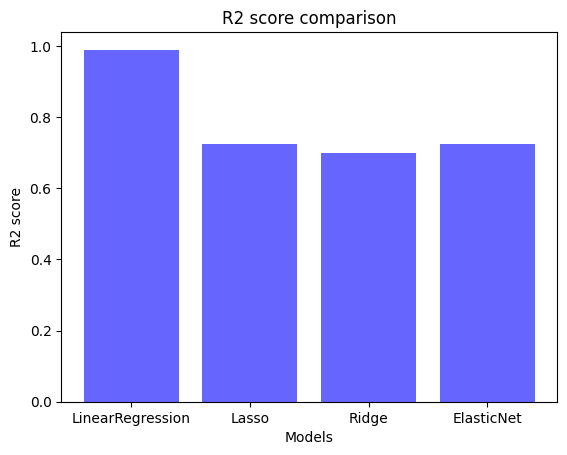

In [20]:
# R2 score comparison
data = {
    'LinearRegression':r2_score(y_test, y_pred),
    'Lasso':r2_score(y_test, y_pred_ls),
    'Ridge':r2_score(y_test, y_pred_r),
    'ElasticNet':r2_score(y_test, y_pred_en)
}

plt.bar(data.keys(), data.values(), color = 'blue', alpha = 0.6)
plt.xlabel('Models')
plt.ylabel('R2 score')
plt.title('R2 score comparison')
plt.show()

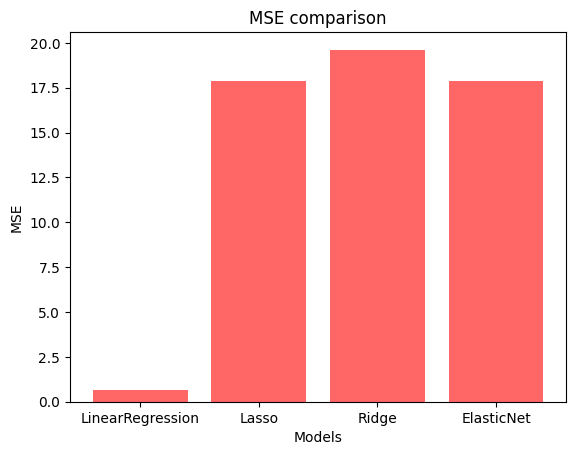

In [21]:
# errors - MSE
from sklearn.metrics import mean_squared_error
data_mse = {
'LinearRegression' : mean_squared_error(y_test, y_pred),
'Lasso': mean_squared_error(y_test,y_pred_ls),
'Ridge':mean_squared_error(y_test, y_pred_r),
'ElasticNet':mean_squared_error(y_test, y_pred_en)
}

plt.bar(data_mse.keys(), data_mse.values(), color = 'red', alpha = 0.6)
plt.xlabel('Models')
plt.ylabel('MSE')
plt.title('MSE comparison')
plt.show()